# rustic_ml — Pipeline Smoke Tests

Verifies the Phase 0 data pipeline end-to-end:
- ADSR encoding round-trip
- Single render → mel spectrogram
- Dataset generation + NpzDataset loading
- Perceptual loss forward pass

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import tempfile

import rustic_ml
from rustic_ml import (
    encode_adsr, decode_adsr, NOTE_MIN, NOTE_MAX, N_NOTES, WAVEFORMS,
    random_spec, render_mel, generate_dataset, NpzDataset,
    MultiScaleSTFTLoss, LogMelL1Loss, PerceptualLoss,
)

print('rustic_ml imported OK')
print('WAVEFORMS:', WAVEFORMS)
print(f'NOTE range: [{NOTE_MIN}, {NOTE_MAX}]  N_NOTES={N_NOTES}')

rustic_ml imported OK
WAVEFORMS: ['sine', 'square', 'saw', 'triangle', 'whitenoise', 'pinknoise', 'blank']
NOTE range: [36, 84]  N_NOTES=49


## 1 — ADSR encoding round-trip

In [2]:
test_cases = [
    (0.001, 0.001, 0.0,  0.001),   # minimum values
    (2.0,   2.0,   1.0,  2.0),     # maximum values
    (0.1,   0.3,   0.7,  0.5),     # typical
    (0.01,  0.4,   0.0,  0.05),    # pluck (sustain=0)
    (0.3,   0.1,   0.9,  0.4),     # slow pad
]

print(f'{'Input':40s}  {'Encoded':35s}  {'Decoded':40s}  Match')
print('-' * 130)
all_ok = True
for a, d, s, r in test_cases:
    enc = encode_adsr(a, d, s, r)
    dec = decode_adsr(enc)
    ok = np.allclose([a, d, s, r], dec, rtol=1e-5)
    all_ok = all_ok and ok
    print(f'A={a:.3f} D={d:.3f} S={s:.3f} R={r:.3f}  →  {enc}  →  A={dec[0]:.4f} D={dec[1]:.4f} S={dec[2]:.4f} R={dec[3]:.4f}  {"OK" if ok else "FAIL"}')

print()
print('All round-trips OK:', all_ok)

Input                                     Encoded                              Decoded                                   Match
----------------------------------------------------------------------------------------------------------------------------------
A=0.001 D=0.001 S=0.000 R=0.001  →  [-6.9077554 -6.9077554  0.        -6.9077554]  →  A=0.0010 D=0.0010 S=0.0000 R=0.0010  OK
A=2.000 D=2.000 S=1.000 R=2.000  →  [0.6931472 0.6931472 1.        0.6931472]  →  A=2.0000 D=2.0000 S=1.0000 R=2.0000  OK
A=0.100 D=0.300 S=0.700 R=0.500  →  [-2.3025851 -1.2039728  0.7       -0.6931472]  →  A=0.1000 D=0.3000 S=0.7000 R=0.5000  OK
A=0.010 D=0.400 S=0.000 R=0.050  →  [-4.6051702  -0.91629076  0.         -2.9957323 ]  →  A=0.0100 D=0.4000 S=0.0000 R=0.0500  OK
A=0.300 D=0.100 S=0.900 R=0.400  →  [-1.2039728  -2.3025851   0.9        -0.91629076]  →  A=0.3000 D=0.1000 S=0.9000 R=0.4000  OK

All round-trips OK: True


## 2 — Single render → mel spectrogram

note=56  A=0.024 D=0.008 S=0.391 R=0.001
Mel shape: (128, 87)  dtype: float32  range: [-80.0, 0.0] dB


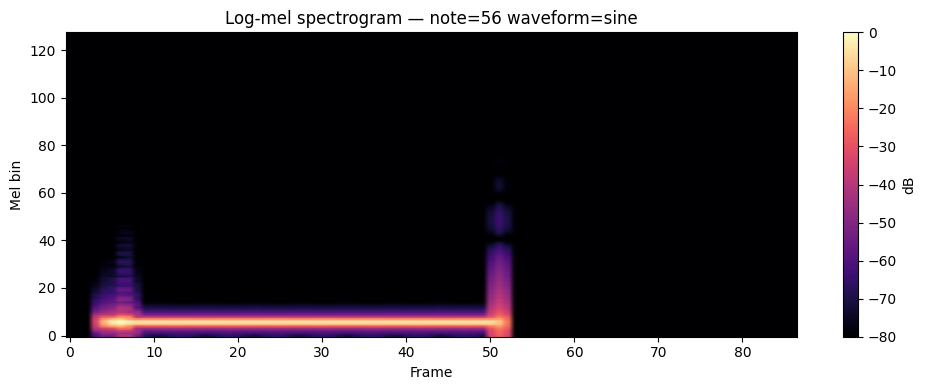

In [3]:
spec = random_spec(waveform='sine')
src = spec['source']
print(f"note={spec['note']}  A={src['attack']:.3f} D={src['decay']:.3f} S={src['sustain']:.3f} R={src['release']:.3f}")

mel = render_mel(spec)
print(f'Mel shape: {mel.shape}  dtype: {mel.dtype}  range: [{mel.min():.1f}, {mel.max():.1f}] dB')

plt.figure(figsize=(10, 4))
plt.imshow(mel, aspect='auto', origin='lower', cmap='magma')
plt.colorbar(label='dB')
plt.title(f"Log-mel spectrogram — note={spec['note']} waveform=sine")
plt.xlabel('Frame')
plt.ylabel('Mel bin')
plt.tight_layout()
plt.show()

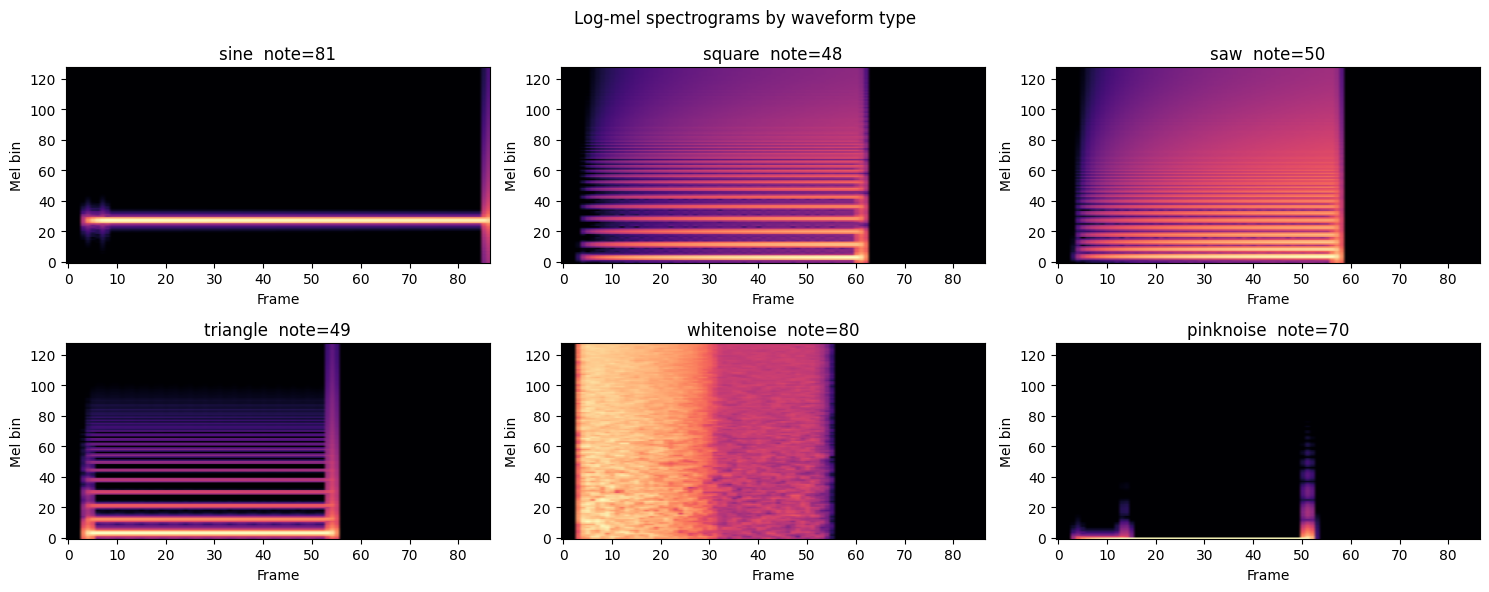

In [4]:
# Visualise a few waveforms side by side
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
waveforms_to_show = ['sine', 'square', 'saw', 'triangle', 'whitenoise', 'pinknoise']

for ax, wf in zip(axes.flat, waveforms_to_show):
    s = random_spec(waveform=wf)
    m = render_mel(s)
    ax.imshow(m, aspect='auto', origin='lower', cmap='magma', vmin=-80, vmax=0)
    ax.set_title(f'{wf}  note={s["note"]}')
    ax.set_xlabel('Frame')
    ax.set_ylabel('Mel bin')

plt.suptitle('Log-mel spectrograms by waveform type')
plt.tight_layout()
plt.show()

## 3 — Dataset generation + NpzDataset

In [5]:
import os

tmp_dir = tempfile.mkdtemp(prefix='rustic_ml_test_')
print(f'Output dir: {tmp_dir}')

generate_dataset(n_samples=50, output_dir=tmp_dir, batch_size=20)

files = sorted(os.listdir(tmp_dir))
print(f'Generated files: {files}')

# Inspect one file
import numpy as np_
data = np_.load(os.path.join(tmp_dir, files[0]))
print(f"\nbatch_0000.npz keys: {list(data.keys())}")
print(f"  mel:  {data['mel'].shape}  {data['mel'].dtype}")
print(f"  note: {data['note'].shape}  {data['note'].dtype}  values: {data['note']}")
print(f"  adsr: {data['adsr'].shape}  {data['adsr'].dtype}")

Output dir: /tmp/rustic_ml_test_ykai0v_f


Generating dataset: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:01<00:00, 35.51it/s]

Generated files: ['batch_0000.npz', 'batch_0001.npz', 'batch_0002.npz']

batch_0000.npz keys: ['mel', 'note', 'adsr']
  mel:  (20, 128, 87)  float32
  note: (20,)  int32  values: [44 46 77 45 53 46 46 67 53 79 75 59 36 52 64 60 75 51 38 46]
  adsr: (20, 4)  float32


In [6]:
ds = NpzDataset(tmp_dir)
print(f'Dataset length: {len(ds)}')

mel_t, note, adsr_t = ds[0]
print(f'\nds[0]:')
print(f'  mel:  {mel_t.shape}  {mel_t.dtype}')
print(f'  note: {note}  (type: {type(note).__name__})')
print(f'  adsr: {adsr_t.shape}  {adsr_t.dtype}  values: {adsr_t}')

# Spot-check a few items
for i in [0, 10, 25, 49]:
    m, n, a = ds[i]
    print(f'  ds[{i:2d}]: mel={tuple(m.shape)}  note={n:3d}  adsr={a.tolist()}')

Dataset length: 50

ds[0]:
  mel:  torch.Size([1, 128, 87])  torch.float32
  note: 44  (type: int)
  adsr: torch.Size([4])  torch.float32  values: tensor([-4.6204, -5.6106,  0.5305, -1.8215])
  ds[ 0]: mel=(1, 128, 87)  note= 44  adsr=[-4.620401859283447, -5.610589027404785, 0.5304597616195679, -1.8214703798294067]
  ds[10]: mel=(1, 128, 87)  note= 75  adsr=[-0.9888242483139038, -2.6029746532440186, 0.30972614884376526, 0.5526960492134094]
  ds[25]: mel=(1, 128, 87)  note= 75  adsr=[-0.3773876428604126, -3.268322706222534, 0.6795960068702698, -0.6540772318840027]
  ds[49]: mel=(1, 128, 87)  note= 66  adsr=[-0.5457354784011841, -4.708083629608154, 0.09534735232591629, -2.972196340560913]


## 4 — Perceptual loss forward pass

In [7]:
import torch

T = 44100  # 1 second
B = 2

pred   = torch.randn(B, T)
target = torch.randn(B, T)

stft_loss = MultiScaleSTFTLoss()
mel_loss  = LogMelL1Loss()
perc_loss = PerceptualLoss(lambda_=1.0)

l_stft = stft_loss(pred, target)
l_mel  = mel_loss(pred, target)
l_perc = perc_loss(pred, target)

print(f'MultiScaleSTFTLoss : {l_stft.item():.6f}  nan={torch.isnan(l_stft).item()}')
print(f'LogMelL1Loss       : {l_mel.item():.6f}  nan={torch.isnan(l_mel).item()}')
print(f'PerceptualLoss     : {l_perc.item():.6f}  nan={torch.isnan(l_perc).item()}')
print(f'Expected: stft + mel ≈ {l_stft.item() + l_mel.item():.6f}  got: {l_perc.item():.6f}')

MultiScaleSTFTLoss : 0.702125  nan=False
LogMelL1Loss       : 0.637445  nan=False
PerceptualLoss     : 1.339570  nan=False
Expected: stft + mel ≈ 1.339570  got: 1.339570


In [8]:
# Loss should be lower when pred ≈ target
near_target = target + 0.001 * torch.randn_like(target)
far_target  = torch.randn(B, T)

l_near = perc_loss(near_target, target)
l_far  = perc_loss(far_target,  target)

print(f'Loss (pred ≈ target): {l_near.item():.6f}')
print(f'Loss (pred random)  : {l_far.item():.6f}')
print(f'Ordering correct (near < far): {l_near.item() < l_far.item()}')

Loss (pred ≈ target): 0.001787
Loss (pred random)  : 1.337771
Ordering correct (near < far): True


In [9]:
# Sanity: loss is differentiable
pred_grad = torch.randn(B, T, requires_grad=True)
loss = perc_loss(pred_grad, target)
loss.backward()
print(f'Gradient norm: {pred_grad.grad.norm().item():.6f}  (non-zero = differentiable OK)')

amdgpu.ids: No such file or directory


Gradient norm: 0.090318  (non-zero = differentiable OK)
